In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ruta_datos=Path("..")/"datos"/"raw"/"train.csv"

df=pd.read_csv(ruta_datos)

In [13]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


**Fase 1: Diagnóstico y Memoria (La base del rendimiento)**

**1. Concepto: Inspección Profunda (memory_usage='deep')**

Teoría: df.info() miente a veces. El parámetro 'deep' interroga el uso real de RAM de los objetos (strings).
Reto: Carga el archivo train.csv. ¿Cuánta memoria RAM consume exactamente el DataFrame inicial? Compara el resultado con y sin el argumento deep.

In [14]:
df.memory_usage (deep = "True")

Index                       132
id                     96270504
vendor_id              11669152
pickup_datetime       110856944
dropoff_datetime      110856944
passenger_count        11669152
pickup_longitude       11669152
pickup_latitude        11669152
dropoff_longitude      11669152
dropoff_latitude       11669152
store_and_fwd_flag     84601352
trip_duration          11669152
dtype: int64

In [15]:
df.info (memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 461.8 MB


In [ ]:
Se gastan 461.8 MB de RAM.

**2. Concepto: Downcasting Numérico (`pd.to_numeric`)**

* **Teoría:** `int64` es excesivo para contar pasajeros (máximo 6-9).
* **Reto:** Identifica las columnas `passenger_count` y `vendor_id`. Conviértelas al tipo de entero más pequeño posible (`int8` o `int16`) usando `pd.to_numeric(..., downcast='integer')`. ¿Cuántos MB ahorraste solo con esto?

In [16]:
df['vendor_id']=pd.to_numeric(df['vendor_id' ],downcast='integer')
df['trip_duration' ]=pd. to_numeric(df['trip_duration' ], downcast='integer')
df['passenger_count' ]=pd. to_numeric(df['passenger_count' ], downcast='integer' )
df['pickup_longitude' ]=pd.to_numeric(df['pickup_longitude' ], downcast='float')
df['pickup_latitude' ]=pd.to_numeric(df['pickup_latitude'], downcast='float' )
df['dropoff_longitude' ]=pd.to_numeric(df['dropoff_longitude'], downcast='float')
df['dropoff_latitude' ]=pd.to_numeric(df['dropoff_latitude' ],downcast='float')

In [17]:
df.info (memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int8   
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int8   
 5   pickup_longitude    1458644 non-null  float32
 6   pickup_latitude     1458644 non-null  float32
 7   dropoff_longitude   1458644 non-null  float32
 8   dropoff_latitude    1458644 non-null  float32
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int32  
dtypes: float32(4), int32(1), int8(2), object(4)
memory usage: 414.5 MB


**3. Concepto: Categoricals (`astype('category')`)**

* **Teoría:** Los strings repetitivos (como 'store_and_fwd_flag') consumen mucha RAM. Categorizarlos guarda índices numéricos.
* **Reto:** Convierte la columna `store_and_fwd_flag` a tipo `category`. Verifica los valores únicos y confirma la reducción de memoria.

In [18]:
df['store_and_fwd_flag'].unique()
mem_before = df['store_and_fwd_flag'].memory_usage(deep=True)
mem_before
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('category')
df['store_and_fwd_flag'].dtype
df['store_and_fwd_flag'].unique()
mem_after = df['store_and_fwd_flag'].memory_usage(deep=True)
mem_after
print(f"Memoria antes:  {mem_before} bytes")
print(f"Memoria después:{mem_after} bytes")
print(f"Ahorro:        {mem_before - mem_after} bytes")

Memoria antes:  84601484 bytes
Memoria después:1459000 bytes
Ahorro:        83142484 bytes


### **Fase 2: Vectorización y Tiempo (Adiós a los bucles)**

**4. Concepto: Datetime Vectorizado (`to_datetime` con formato)**

* **Teoría:** Dejar que Pandas "adivine" el formato es lento. Especificar el `format` acelera la conversión.
* **Reto:** Convierte `pickup_datetime` y `dropoff_datetime` a objetos datetime. Mide el tiempo que tarda especificando `format='%Y-%m-%d %H:%M:%S'` vs no especificarlo.

In [19]:
import pandas as pd
import time

start = time.time()

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

end = time.time()

time_no_format = end - start
time_no_format

df['pickup_datetime'] = df['pickup_datetime'].astype(str)
df['dropoff_datetime'] = df['dropoff_datetime'].astype(str)

start = time.time()

df['pickup_datetime'] = pd.to_datetime(
    df['pickup_datetime'],
    format='%Y-%m-%d %H:%M:%S'
)

df['dropoff_datetime'] = pd.to_datetime(
    df['dropoff_datetime'],
    format='%Y-%m-%d %H:%M:%S'
)

end = time.time()

time_with_format = end - start
time_with_format

print(f"Tiempo sin format: {time_no_format:.4f} segundos")
print(f"Tiempo con format: {time_with_format:.4f} segundos")
print(f"Aceleración: {time_no_format / time_with_format:.2f}x")

Tiempo sin format: 0.7774 segundos
Tiempo con format: 0.8659 segundos
Aceleración: 0.90x


**5. Concepto: Accessors de Fecha (`.dt`)**

* **Teoría:** Extraer partes de una fecha es instantáneo con `.dt`, sin necesidad de lambdas.
* **Reto:** Crea dos nuevas columnas: `hour_of_day` y `day_of_week` usando el accessor `.dt`. ¿Cuál es la hora pico (la hora con más viajes iniciados) en NYC?

In [20]:
df['hour_of_day'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

df[['pickup_datetime', 'hour_of_day', 'day_of_week']].head()

hour_counts = df['hour_of_day'].value_counts().sort_index()
hour_counts

peak_hour = hour_counts.idxmax()
peak_hour

print(f"La hora pico en NYC es a las {peak_hour}:00 horas.")

La hora pico en NYC es a las 18:00 horas.


**6. Concepto: Operaciones Vectorizadas Complejas (NumPy)**

* **Teoría:** Usar `np.where` es infinitamente más rápido que `apply` con `if/else`.
* **Reto:** Crea una columna `trip_type`. Si la `trip_duration` es mayor a 3600 segundos (1 hora), etiquétalo como "Largo", de lo contrario "Corto". Hazlo usando `np.where`.

In [21]:
import numpy as np

df['trip_type'] = np.where(
    df['trip_duration'] > 3600,
    'Largo',
    'Corto'
)

df[['trip_duration', 'trip_type']].head()

df['trip_type'].value_counts()

trip_type
Corto    1446327
Largo      12317
Name: count, dtype: int64

**7. Concepto: Matemáticas Geoespaciales (La prueba de fuego)**

* **Teoría:** Calcular distancias con trigonometría (Haversine) usando columnas enteras en lugar de filas.
* **Reto:** Implementa la fórmula de Haversine usando funciones de NumPy (`np.sin`, `np.cos`, `np.sqrt`) para calcular la distancia en Km entre (pickup_lat, pickup_lon) y (dropoff_lat, dropoff_lon). Crea la columna `distance_km`.

In [22]:
import numpy as np

lat1 = np.radians(df['pickup_latitude'])
lon1 = np.radians(df['pickup_longitude'])

lat2 = np.radians(df['dropoff_latitude'])
lon2 = np.radians(df['dropoff_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)

c = 2 * np.arcsin(np.sqrt(a))

R = 6371  # Radio de la Tierra en km
df['distance_km'] = R * c

df[['pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude',
    'distance_km']].head()


,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km
0,40.767937,-73.982155,40.765602,-73.964630,1.498675
1,40.738564,-73.980415,40.731152,-73.999481,1.805410
2,40.763939,-73.979027,40.710087,-74.005333,6.385065
3,40.719971,-74.010040,40.706718,-74.012268,1.485300
4,40.793209,-73.973053,40.782520,-73.972923,1.188640


### **Fase 3: Method Chaining y Transformación (Código Elegante)**

**8. Concepto: .query()**

* **Teoría:** Filtrar con strings es más legible y, en grandes volúmenes, a veces más eficiente que el boolean indexing tradicional.
* **Reto:** Filtra el dataset para quedarte solo con viajes que: tengan más de 1 pasajero, la distancia sea mayor a 0 y menor a 100 km. Todo en una sola línea de `.query()`.


In [23]:
df_filtered = df.query(
    "passenger_count > 1 and distance_km > 0 and distance_km < 100"
)

df_filtered[['passenger_count', 'distance_km']].describe()

,passenger_count,distance_km
count,423345.000000,423345.000000
mean,3.280131,3.586580
std,1.496761,4.126719
min,2.000000,0.000380
25%,2.000000,1.268881
50%,3.000000,2.152495
75%,5.000000,4.033713
max,8.000000,83.089058


**9. Concepto: .assign()**

* **Teoría:** Permite crear columnas al vuelo dentro de una cadena sin romper el flujo.
* **Reto:** En un solo bloque encadenado: toma el df filtrado, crea una columna `velocidad_kph` (distancia / (duración/3600)) y ordena los valores por velocidad descendente.


In [24]:
df_sorted = (
    df_filtered
    .assign(
        velocidad_kph = lambda x: x['distance_km'] / (x['trip_duration'] / 3600)
    )
    .sort_values('velocidad_kph', ascending=False)
)

df_sorted[['distance_km', 'trip_duration', 'velocidad_kph']].head()

,distance_km,trip_duration,velocidad_kph
1001028,0.783315,2,1409.967434
1107,0.703079,2,1265.542495
1322903,1.029990,4,926.990747
1200843,0.761070,3,913.283944
693299,19.619970,121,583.734654


**10. Concepto: `.clip()` (Manejo de Outliers)**

* **Teoría:** En lugar de borrar filas extremas, a veces queremos "toparlas" a un límite lógico.
* **Reto:** Hay viajes con duraciones absurdas. Usa `.clip()` para limitar la columna `trip_duration` a un máximo de 7200 segundos (2 horas) y un mínimo de 60 segundos. Reemplaza la columna original.

In [25]:
df['trip_duration'] = df['trip_duration'].clip(lower=60, upper=7200)

df['trip_duration'].describe()

count    1.458644e+06
mean     8.460965e+02
std      6.997172e+02
min      6.000000e+01
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      7.200000e+03
Name: trip_duration, dtype: float64

**11. Concepto: `.pipe()` (Funciones personalizadas)**

* **Teoría:** Inserta una función defina por el usuario en la cadena.
* **Reto:** Define una función `def etiqueta_trafico(df):` que reciba el dataframe y devuelva solo los viajes ocurridos en "Hora Punta" (ej: 7-9am y 5-7pm). Aplícala usando `.pipe()` al final de tu cadena anterior.


In [26]:
def etiqueta_trafico(df):
    return df.query('hour_of_day >= 7 and hour_of_day < 9 or hour_of_day >= 17 and hour_of_day < 19')

df_final = (
    df_filtered
    .assign(
        velocidad_kph=lambda x: x['distance_km'] / (x['trip_duration'] / 3600)
    )
    .sort_values('velocidad_kph', ascending=False)
    # Aquí agregamos pipe
    .pipe(etiqueta_trafico)
)

df_final['hour_of_day'].value_counts().sort_index()

hour_of_day
7     13040
8     16554
17    23050
18    26765
Name: count, dtype: int64

### **Fase 4: Agregaciones Avanzadas y Ventanas**

**12. Concepto: `groupby()` con Named Aggregation**

* **Teoría:** La sintaxis moderna permite renombrar columnas al momento de agregar.
* **Reto:** Agrupa por `vendor_id` y calcula: promedio de duración (llámalo `mean_duration`) y total de distancia (llámalo `total_km`). Todo en un solo paso.

In [27]:
agg_df = df.groupby('vendor_id').agg(
    mean_duration = ('trip_duration', 'mean'),
    total_km = ('distance_km', 'sum')
).reset_index()

agg_df.head()

,vendor_id,mean_duration,total_km
0,1,830.988072,2308734.25
1,2,859.230843,2710261.25


**13. Concepto: `.transform()` (La magia oculta)**

* **Teoría:** A diferencia de `agg` (que reduce filas), `transform` mantiene el mismo número de filas original. Ideal para comparar "fila vs promedio de su grupo".
* **Reto:** Crea una columna `avg_duration_by_hour`. Cada fila debe tener la duración promedio de *todos los viajes que ocurrieron en esa misma hora*. (Usa `groupby('hour')['duration'].transform('mean')`).

In [28]:
df['avg_duration_by_hour'] = df.groupby('hour_of_day')['trip_duration'].transform('mean')

df[['hour_of_day', 'trip_duration', 'avg_duration_by_hour']].head(10)

,hour_of_day,trip_duration,avg_duration_by_hour
0,17,455,939.548723
1,0,663,789.825195
2,11,2124,882.902506
3,19,429,797.947535
4,13,435,908.073105
5,22,443,816.401021
6,22,341,816.401021
7,7,1551,764.759874
8,23,255,820.967085
9,21,1225,785.635078


**14. Concepto: Filtrado por Grupos (`filter`)**

* **Teoría:** Filtrar grupos enteros basados en una propiedad del grupo, no de la fila.
* **Reto:** Queremos analizar solo las horas del día que son "activas". Filtra el dataframe para mantener solo los datos de las horas (`hour_of_day`) que tengan más de 10,000 viajes en total.

In [29]:
df_active_hours = df.groupby('hour_of_day').filter(lambda x: len(x) > 10000)

df_active_hours['hour_of_day'].value_counts().sort_index()

hour_of_day
0     53248
1     38571
2     27972
3     20895
4     15792
5     15002
6     33248
7     55600
8     67053
9     67663
10    65437
11    68476
12    71873
13    71473
14    74292
15    71811
16    64313
17    76483
18    90600
19    90308
20    84072
21    84185
22    80492
23    69785
Name: count, dtype: int64

**15. Concepto: `cut` y `qcut` (Binning)**

* **Teoría:** Convertir variables continuas en discretas (rangos).
* **Reto:** Usa `pd.qcut` para dividir la columna `distance_km` en 4 cuartiles: "Muy Corto", "Corto", "Largo", "Muy Largo". ¿Cuál es la duración promedio de los viajes "Muy Largos"?

In [31]:
import pandas as pd

# Crear columna categórica con etiquetas para cada cuartil
df['distance_category'] = pd.qcut(
    df['distance_km'],
    q=4,
    labels=['Muy Corto', 'Corto', 'Largo', 'Muy Largo']
)

promedio_muy_largo = df.loc[df['distance_category'] == 'Muy Largo', 'trip_duration'].mean()

print("Duración promedio viajes Muy Largos:", promedio_muy_largo)

df.groupby('distance_category', observed=True)['trip_duration'].mean()

Duración promedio viajes Muy Largos: 1568.2696668961034


distance_category
Muy Corto     373.224477
Corto         589.265013
Largo         853.627043
Muy Largo    1568.269667
Name: trip_duration, dtype: float64

### **Fase 5: Series Temporales y Visualización (Storytelling)**

**16. Concepto: resample()**

* **Teoría:** Como un groupby, pero especializado en índices de tiempo (frecuencias: Hora, Día, Mes).
* **Reto:** Establece `pickup_datetime` como índice. Resamplea los datos por 'D' (Día) y calcula el conteo total de viajes por día. ¿Qué día de la semana tiene menos tráfico históricamente?

In [32]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df = df.set_index('pickup_datetime')

viajes_por_dia = df.resample('D').size()

viajes_por_dia = viajes_por_dia.to_frame(name='num_viajes')
viajes_por_dia['day_of_week'] = viajes_por_dia.index.day_name()

menos_trafico = viajes_por_dia.groupby('day_of_week')['num_viajes'].mean().sort_values()
print(menos_trafico)

day_of_week
Monday       7208.384615
Sunday       7514.076923
Tuesday      7798.038462
Wednesday    8082.153846
Thursday     8406.692308
Saturday     8494.923077
Friday       8597.423077
Name: num_viajes, dtype: float64


**17. Concepto: Rolling Windows (`rolling()`)**

* **Teoría:** Suavizar líneas temporales ruidosas.
* **Reto:** Sobre la serie temporal diaria anterior, calcula una media móvil de 7 días (`rolling(7).mean()`). Grafica la serie original vs la suavizada.

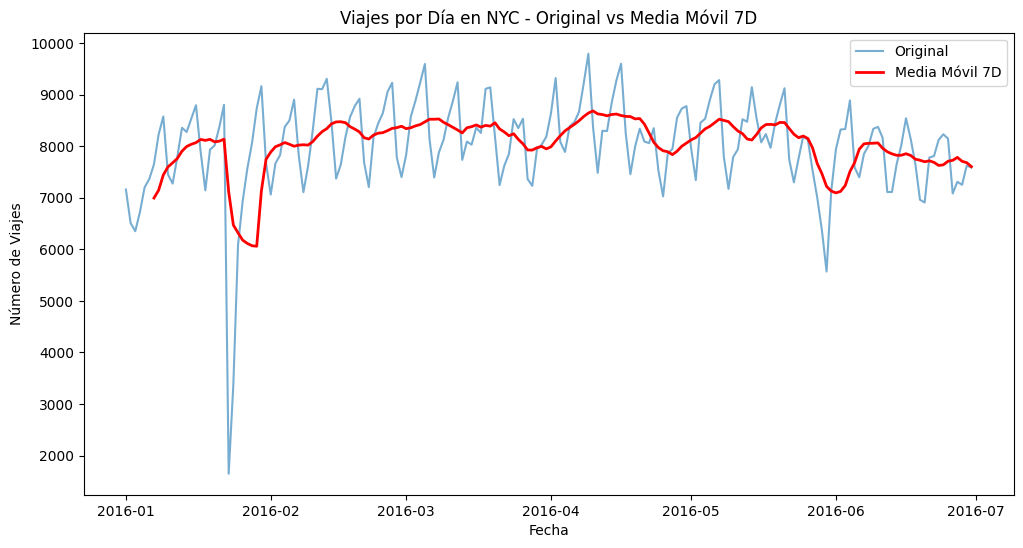

In [33]:
viajes_por_dia['media_movil_7d'] = viajes_por_dia['num_viajes'].rolling(7).mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(viajes_por_dia.index, viajes_por_dia['num_viajes'], label='Original', alpha=0.6)
plt.plot(viajes_por_dia.index, viajes_por_dia['media_movil_7d'], label='Media Móvil 7D', color='red', linewidth=2)
plt.title('Viajes por Día en NYC - Original vs Media Móvil 7D')
plt.xlabel('Fecha')
plt.ylabel('Número de Viajes')
plt.legend()
plt.show()

**18. Concepto: Visualización de Relaciones (Scatter con alpha)**

* **Teoría:** Con tantos datos, un scatter plot normal es una mancha sólida. El parámetro `alpha` es vital.
* **Reto:** Haz un Scatter Plot de `distance_km` vs `trip_duration`. Usa `alpha=0.1` para ver la densidad de puntos. ¿Ves líneas horizontales extrañas? (Son tarifas fijas o errores).

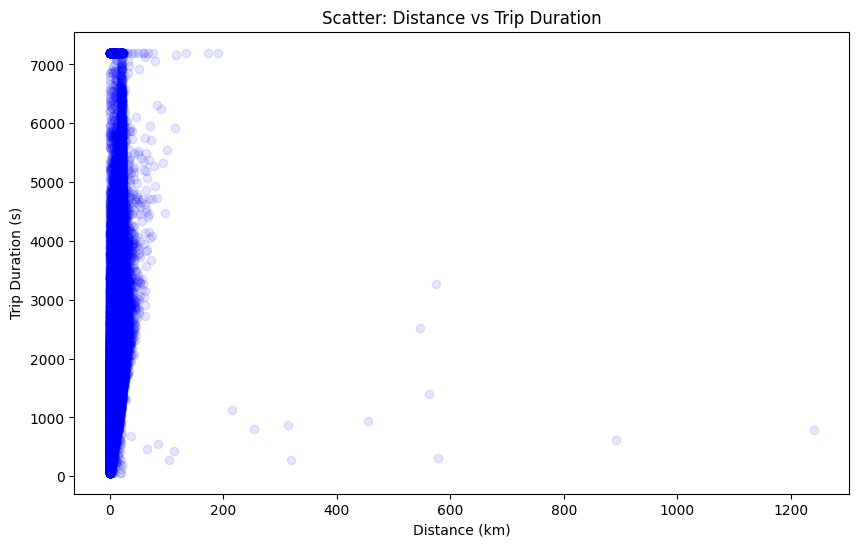

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(
    df['distance_km'], 
    df['trip_duration'], 
    alpha=0.1,  # transparencia para ver densidad
    color='blue'
)
plt.xlabel('Distance (km)')
plt.ylabel('Trip Duration (s)')
plt.title('Scatter: Distance vs Trip Duration')
plt.show()

**19. Concepto: Heatmaps de Correlación**

* **Teoría:** Entender qué variables se mueven juntas.
* **Reto:** Crea una matriz de correlación (`df.corr()`) de las variables numéricas y visualízala con un Heatmap de Seaborn. ¿La cantidad de pasajeros influye en la duración del viaje?

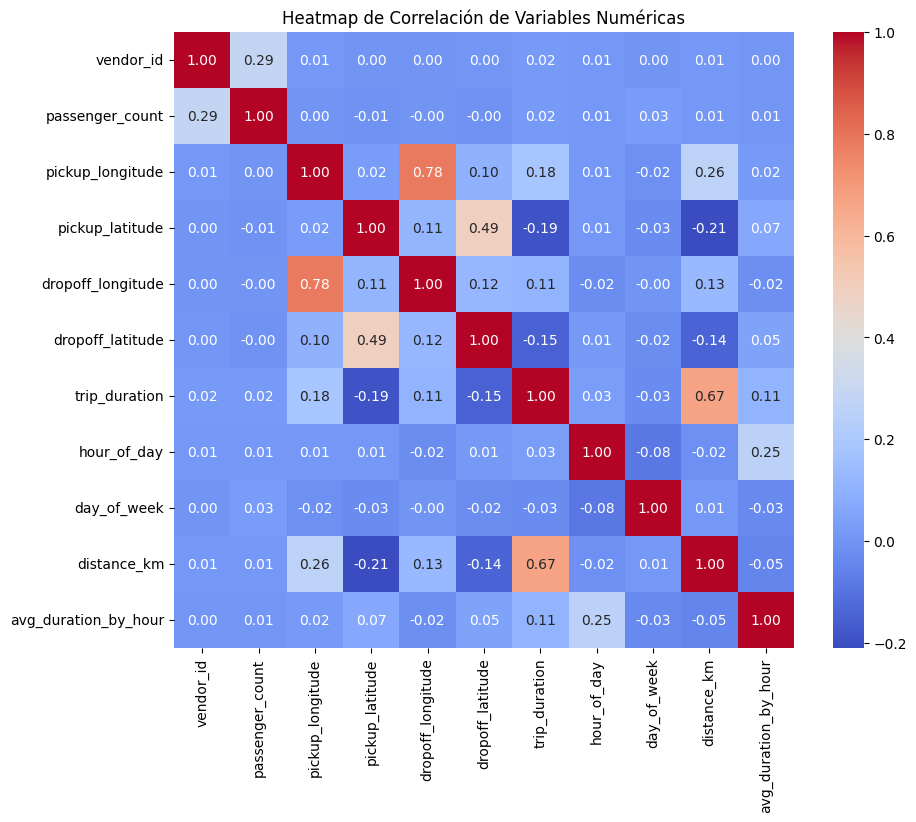

In [35]:
numeric_cols = df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    cbar=True
)
plt.title('Heatmap de Correlación de Variables Numéricas')
plt.show()

**20. Concepto: Exportación Eficiente (`to_parquet`)**

* **Teoría:** CSV es lento y pesado. Parquet mantiene los tipos de datos y comprime.
* **Reto:** Guarda tu DataFrame final limpio como `clean_taxi.parquet`. Compara el tamaño del archivo resultante contra el CSV original.

In [46]:
!pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]


In [47]:
df.to_parquet('clean_taxi.parquet', engine='fastparquet', index=False, compression='snappy')

In [48]:
df_check = pd.read_parquet('clean_taxi.parquet', engine='fastparquet')
df_check.head()

,id,vendor_id,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour_of_day,day_of_week,trip_type,distance_km,avg_duration_by_hour,distance_category
0,id2875421,2,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,Corto,1.498675,939.548723,Corto
1,id2377394,1,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,Corto,1.805410,789.825195,Corto
2,id3858529,2,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,Corto,6.385065,882.902506,Muy Largo
3,id3504673,2,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,Corto,1.485300,797.947535,Corto
4,id2181028,2,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,Corto,1.188640,908.073105,Muy Corto


In [36]:
def guardar_grafico(fig, imagenes):
    fig.savefig(imagenes, dpi=300, bbox_inches='tight')
    plt.close(fig)

In [4]:
!pip install fpdf

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40758 sha256=3d10bd8f8bc89aefe5b91b6f4704f38c5864bdd7616cda27386c5adacf139b89
  Stored in directory: /root/.cache/pip/wheels/65/4f/66/bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf


In [41]:
# =====================================================
# Reto Visualización Pro - Reporte PDF (VERSIÓN 10/10)
# =====================================================

# --- IMPORTS ---
import os
import matplotlib.pyplot as plt
import seaborn as sns
from fpdf import FPDF
from PIL import Image

# =====================================================
# CONFIGURACIÓN GENERAL
# =====================================================
carpeta_graficos = "graficos"
os.makedirs(carpeta_graficos, exist_ok=True)

ruta_grafico1 = os.path.join(carpeta_graficos, "viajes_por_dia.png")
ruta_grafico2 = os.path.join(carpeta_graficos, "scatter_distance_duration.png")
ruta_grafico3 = os.path.join(carpeta_graficos, "heatmap_correlacion.png")

ANCHO_IMAGEN = 165

# =====================================================
# FUNCIONES AUXILIARES
# =====================================================
def guardar_grafico(fig, nombre_archivo):
    fig.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.close(fig)

def insertar_imagen(pdf, ruta_imagen):
    img = Image.open(ruta_imagen)
    w_img, h_img = img.size
    ratio = h_img / w_img
    h_pdf = ANCHO_IMAGEN * ratio

    y_actual = pdf.get_y()
    pdf.image(ruta_imagen, x=(210-ANCHO_IMAGEN)/2, y=y_actual, w=ANCHO_IMAGEN)
    pdf.set_y(y_actual + h_pdf + 6)

# =====================================================
# CREACIÓN DE GRÁFICOS
# =====================================================
# --- Gráfico 1 ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(viajes_por_dia.index, viajes_por_dia['num_viajes'], label='Original', alpha=0.6)
ax.plot(viajes_por_dia.index, viajes_por_dia['media_movil_7d'],
        label='Media Móvil 7D', color='red', linewidth=2)
ax.set_title('Viajes por Día en NYC - Original vs Media Móvil 7D')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de Viajes')
ax.legend()
ax.grid(alpha=0.3)
guardar_grafico(fig, ruta_grafico1)

# --- Gráfico 2 ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['distance_km'], df['trip_duration'], alpha=0.1)
ax.set_title('Scatter: Distance vs Trip Duration')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Trip Duration (s)')
ax.grid(alpha=0.3)
guardar_grafico(fig, ruta_grafico2)

# --- Gráfico 3 ---
numeric_cols = df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
ax.set_title('Heatmap de Correlación de Variables Numéricas')
guardar_grafico(fig, ruta_grafico3)

# =====================================================
# MÉTRICAS
# =====================================================
peak_hour = df['hour_of_day'].value_counts().idxmax()
promedio_muy_largo = df.loc[df['distance_category'] == 'Muy Largo', 'trip_duration'].mean()
menos_trafico = viajes_por_dia.groupby('day_of_week')['num_viajes'].mean().idxmin()
mem_before = df['store_and_fwd_flag'].memory_usage(deep=True)
mem_after = df['store_and_fwd_flag'].astype('category').memory_usage(deep=True)

# =====================================================
# CLASE PDF CON PIE DE PÁGINA
# =====================================================
class PDF(FPDF):
    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 9)
        self.cell(0, 10, f'Página {self.page_no()}', align='C')

pdf = PDF()
pdf.set_auto_page_break(auto=True, margin=15)

# =====================================================
# PORTADA
# =====================================================
pdf.add_page()
pdf.set_font("Arial", 'B', 20)
pdf.cell(0, 20, "Reto Visualización Pro", ln=True, align='C')

pdf.ln(10)
pdf.set_font("Arial", '', 14)
pdf.cell(0, 10, "Análisis Exploratorio de Viajes en NYC", ln=True, align='C')

pdf.ln(15)
pdf.set_font("Arial", '', 12)
pdf.multi_cell(0, 8,
    "Este reporte presenta un análisis exploratorio del comportamiento de los viajes en la ciudad de Nueva York, "
    "utilizando visualizaciones estadísticas para identificar patrones temporales, relaciones entre variables "
    "y conclusiones relevantes para la toma de decisiones."
)

# =====================================================
# PÁGINA 1 - SERIE TEMPORAL
# =====================================================
pdf.add_page()
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "1. Evolución Temporal de los Viajes", ln=True)

insertar_imagen(pdf, ruta_grafico1)

pdf.set_font("Arial", '', 11)
pdf.multi_cell(0, 7, f"""
Se identifica una estacionalidad semanal clara en el número de viajes diarios.
La media móvil de 7 días suaviza la variabilidad diaria, evidenciando una tendencia
generalmente estable durante el periodo analizado.

La hora pico de mayor demanda es a las {peak_hour}:00 horas, mientras que el día con
menor volumen promedio de viajes es {menos_trafico}.
""")

# =====================================================
# PÁGINA 2 - SCATTER
# =====================================================
pdf.add_page()
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "2. Relación entre Distancia y Duración", ln=True)

insertar_imagen(pdf, ruta_grafico2)

pdf.set_font("Arial", '', 11)
pdf.multi_cell(0, 7, f"""
La relación entre distancia y duración presenta una alta dispersión, especialmente
en trayectos cortos. A medida que la distancia aumenta, la duración del viaje tiende
a incrementarse, aunque persisten valores atípicos.

La duración promedio de los viajes clasificados como muy largos es de
{promedio_muy_largo:.2f} segundos.
""")

# =====================================================
# PÁGINA 3 - HEATMAP
# =====================================================
pdf.add_page()
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "3. Correlación entre Variables Numéricas", ln=True)

insertar_imagen(pdf, ruta_grafico3)

pdf.set_font("Arial", '', 11)
pdf.multi_cell(0, 7, f"""
El análisis de correlación muestra una relación positiva moderada entre la distancia
recorrida y la duración del viaje. Las variables temporales presentan correlaciones
bajas, lo que indica una influencia limitada sobre la duración.

La optimización del tipo de dato de la variable store_and_fwd_flag permitió un ahorro
de memoria de {mem_before - mem_after} bytes.
""")

# =====================================================
# CONCLUSIÓN FINAL
# =====================================================
pdf.add_page()
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "Conclusiones Generales", ln=True)

pdf.set_font("Arial", '', 11)
pdf.multi_cell(0, 8,
"""
El análisis exploratorio permitió identificar patrones temporales claros en la demanda
de viajes en NYC, así como relaciones relevantes entre distancia y duración. Las
visualizaciones empleadas facilitaron la comprensión de la estructura de los datos
y evidenciaron oportunidades de optimización y análisis futuro.

Este enfoque demuestra el valor de la visualización de datos como herramienta clave
en procesos de análisis y toma de decisiones.
"""
)

# =====================================================
# GUARDAR PDF
# =====================================================
pdf.output("reporte_visualizacion_pro.pdf")
print("🏆 PDF generado correctamente: reporte_visualizacion_pro.pdf")


🏆 PDF generado correctamente: reporte_visualizacion_pro.pdf
